In [1]:
from google.colab import drive

# mount google drive
drive.mount('/content/drive')
%cd /content/drive/My Drive
!git clone https://github.com/FranciscoLozCoding/cooling_with_code.git
%cd cooling_with_code
!git pull

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/My Drive
fatal: destination path 'cooling_with_code' already exists and is not an empty directory.
/content/drive/My Drive/cooling_with_code
Already up to date.


In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

In [3]:
csv_path = 'data/train/300m_buffer_dataset.csv'  # Adjust the path to your CSV file
df = pd.read_csv(csv_path)

KNN Model with All Features:
Mean Absolute Error (MAE): 0.0025582444401602827
R² Score: 0.9496236679245735


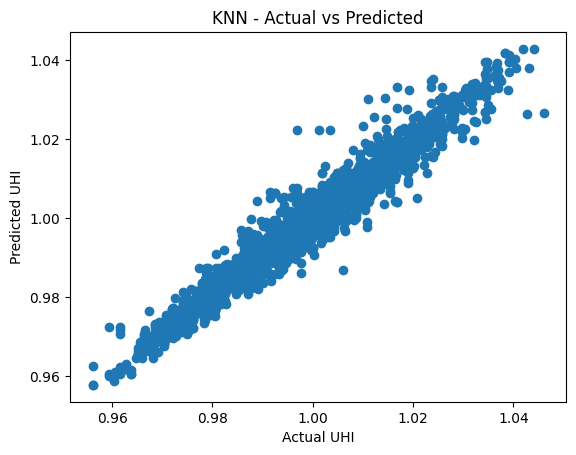

In [4]:
#separating the features and target
X = df.drop(columns=['UHI'])
y = df['UHI']

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the Data into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# building the model
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)

#Evaluate the model
y_pred = knn.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)


print("KNN Model with All Features:")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"R² Score: {r2}")

# Ploting the actual vs predicted values
plt.scatter(y_test, y_pred)
plt.xlabel('Actual UHI')
plt.ylabel('Predicted UHI')
plt.title('KNN - Actual vs Predicted')
plt.show()


In [5]:
from sklearn.metrics import r2_score

# Compute R² for training data (in-sample)
train_r2 = r2_score(y_train, knn.predict(X_train))

# Compute R² for test data (out-sample)
test_r2 = r2_score(y_test, knn.predict(X_test))

print("In-Sample R² (Training):", train_r2)
print("Out-Sample R² (Testing):", test_r2)

In-Sample R² (Training): 0.9716277400274926
Out-Sample R² (Testing): 0.9496236679245735


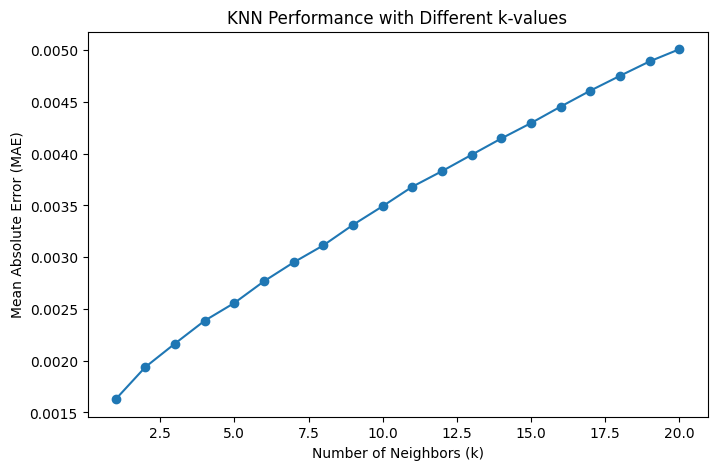

In [6]:
#Hyperparameter Tuning: Trying different values of k
neighbors_range = range(1, 21)
mean_mae = []
for k in neighbors_range:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred_k = knn.predict(X_test)
    mae_k = mean_absolute_error(y_test, y_pred_k)
    mean_mae.append(mae_k)

# Plot the performance with different k-values
plt.figure(figsize=(8, 5))
plt.plot(neighbors_range, mean_mae, marker='o')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Mean Absolute Error (MAE)')
plt.title('KNN Performance with Different k-values')
plt.show()

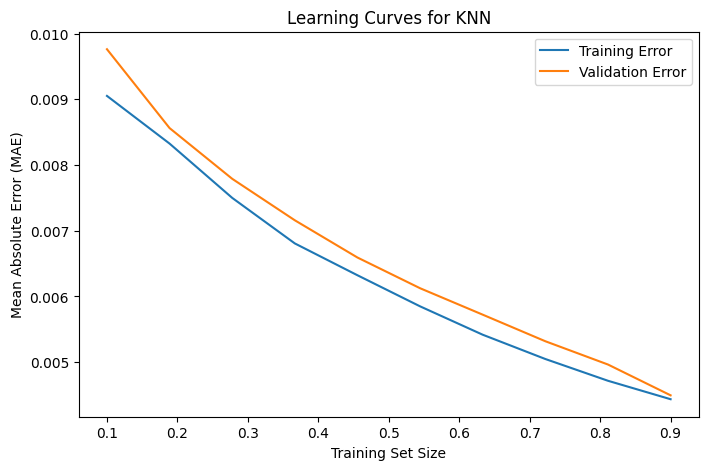

In [7]:
# Learning Curves: Plotting training and validation errors as function of sample size
train_sizes = np.linspace(0.1, 0.9, 10)  # From 10% to 90% of the training data
train_errors = []
val_errors = []

for train_size in train_sizes:
    # Train on a subset of data
    X_train_subset, _, y_train_subset, _ = train_test_split(X_scaled, y, train_size=train_size, random_state=42)

    # Fit the model
    knn.fit(X_train_subset, y_train_subset)

    # Calculate training and validation errors
    train_errors.append(mean_absolute_error(y_train_subset, knn.predict(X_train_subset)))
    val_errors.append(mean_absolute_error(y_test, knn.predict(X_test)))

# Plot learning curves
plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_errors, label='Training Error')
plt.plot(train_sizes, val_errors, label='Validation Error')
plt.xlabel('Training Set Size')
plt.ylabel('Mean Absolute Error (MAE)')
plt.title('Learning Curves for KNN')
plt.legend()
plt.show()


The model has showed great and improved results with the optimal k value. With a 0.0016 MAE and 0.963 R2. This conclude that the model fits the data well and provide accurate prediction of UHI index.



Top Features by Permutation Importance:
                        Feature  Importance
12             Ground_Elevation    0.462192
7                Building_Count    0.345256
5                         NPCRI    0.311539
6               Coastal_Aerosol    0.310280
10              Building_Height    0.254610
13               Traffic_Volume    0.224487
8        Total_Building_Area_m2    0.217442
9              Building_Density    0.217442
3                            SI    0.153627
1                          NDBI    0.133393
4                          NDMI    0.133393
2                          NDWI    0.098159
0                          NDVI    0.087077
11   Building_Construction_Year    0.020704
14   Air Temp at Surface [degC]    0.000000
15  Relative Humidity [percent]    0.000000
16         Avg Wind Speed [m/s]    0.000000
17     Wind Direction [degrees]    0.000000
18           Solar Flux [W/m^2]    0.000000


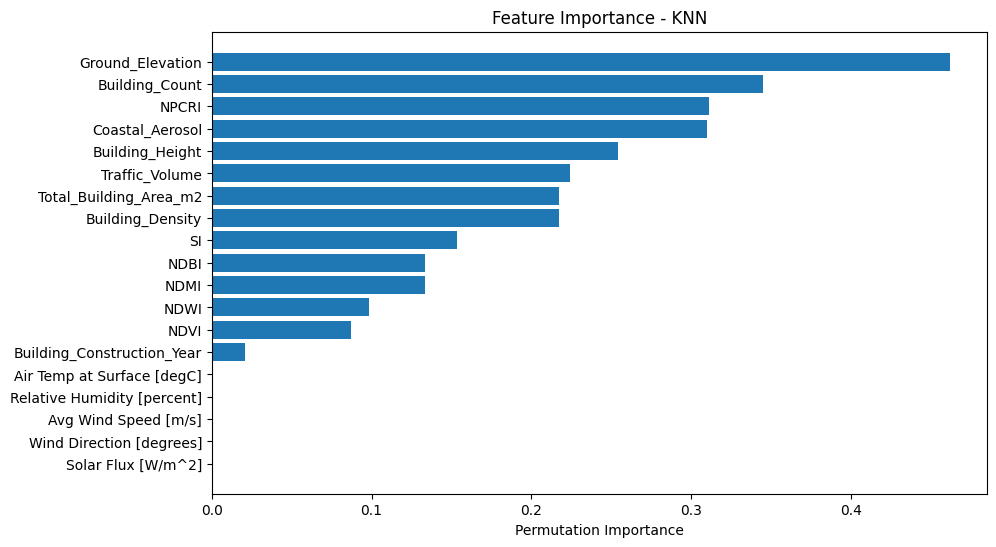

In [8]:
from sklearn.inspection import permutation_importance

# Fit base model
base_knn = KNeighborsRegressor(n_neighbors=5)
base_knn.fit(X_train, y_train)

# Permutation importance
perm_result = permutation_importance(base_knn, X_test, y_test, n_repeats=10, random_state=42)

# Organize results
perm_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': perm_result.importances_mean
}).sort_values(by='Importance', ascending=False)

print("Top Features by Permutation Importance:")
print(perm_df)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(perm_df['Feature'], perm_df['Importance'])
plt.xlabel("Permutation Importance")
plt.title("Feature Importance - KNN")
plt.gca().invert_yaxis()
plt.show()


In [9]:
# List of top features with non-zero importance
top_features = [
    'Ground_Elevation',
    'Building_Count',
    'NPCRI',
    'Coastal_Aerosol',
    'Building_Height',
    'Traffic_Volume',
    'Total_Building_Area_m2',
    'Building_Density',
    'SI',
    'NDBI',
    'NDMI',
    'NDWI',
    'NDVI',
    'Building_Construction_Year'
]

# Reduce dataset to top features
X_reduced = df[top_features]
y = df['UHI']

# Standardize reduced features
scaler = StandardScaler()
X_scaled_reduced = scaler.fit_transform(X_reduced)

# Train-test split
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_scaled_reduced, y, test_size=0.2, random_state=42)


In [11]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_neighbors': list(range(1, 21)),
    'weights': ['uniform', 'distance'],
    'p': [1, 2]  # Euclidean (2), Manhattan (1)
}

grid_search = GridSearchCV(KNeighborsRegressor(), param_grid, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)
grid_search.fit(X_train_r, y_train_r)

print("Best Hyperparameters:", grid_search.best_params_)
print("Best CV MAE:", -grid_search.best_score_)


Best Hyperparameters: {'n_neighbors': 1, 'p': 1, 'weights': 'uniform'}
Best CV MAE: 0.0018447314557769514



 Final Model Performance on Test Set:
MAE: 0.0016
R² Score: 0.9622


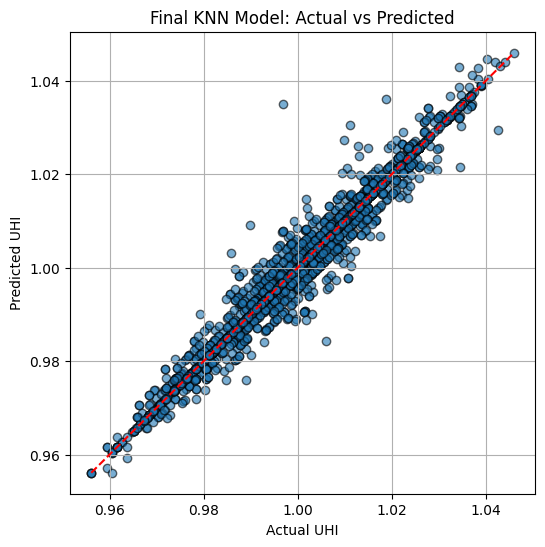

In [12]:
# Final model
best_knn = grid_search.best_estimator_

# Predict on test set
y_pred_final = best_knn.predict(X_test_r)

# Metrics
from sklearn.metrics import mean_absolute_error, r2_score

mae_final = mean_absolute_error(y_test_r, y_pred_final)
r2_final = r2_score(y_test_r, y_pred_final)

print("\n Final Model Performance on Test Set:")
print(f"MAE: {mae_final:.4f}")
print(f"R² Score: {r2_final:.4f}")

# Plot actual vs predicted
plt.figure(figsize=(6, 6))
plt.scatter(y_test_r, y_pred_final, alpha=0.6, edgecolors='k')
plt.plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()], 'r--')
plt.xlabel("Actual UHI")
plt.ylabel("Predicted UHI")
plt.title("Final KNN Model: Actual vs Predicted")
plt.grid(True)
plt.show()


In [13]:
# In-sample R² (Training set)
train_r2_final = r2_score(y_train_r, best_knn.predict(X_train_r))

# Out-sample R² (Test set)
test_r2_final = r2_score(y_test_r, best_knn.predict(X_test_r))

print("Final Model R² Scores:")
print(f"In-Sample R² (Training): {train_r2_final:.4f}")
print(f"Out-Sample R² (Testing): {test_r2_final:.4f}")


Final Model R² Scores:
In-Sample R² (Training): 1.0000
Out-Sample R² (Testing): 0.9622
